In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("VNL2023.csv")

In [6]:
df.head()

,Player,Country,Age,Attack,Block,Serve,Set,Dig,Receive,Position
0,Ichikawa Yuki,Japan,28,15.80,1.13,1.40,0.07,4.80,5.60,OH
1,Romano Yuri,Italy,26,12.33,1.07,1.47,0.00,3.87,0.00,OP
2,Abdel-Aziz Nimir,Nederland,31,15.33,0.67,2.08,0.00,3.17,0.25,OP
3,Herrera Jaime Jesus,Cuba,28,15.00,0.92,1.75,0.00,3.33,0.17,OP
4,Takahashi Ran,Japan,22,11.53,0.67,1.00,0.07,6.40,5.07,OH


In [8]:
df.shape

(131, 10)

In [11]:
df.describe()

,Age,Attack,Block,Serve,Set,Dig,Receive
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,27.809160,5.642672,0.845573,0.535802,2.192595,3.428397,1.684198
std,4.186268,4.256229,0.700896,0.454346,6.031587,2.077823,1.989939
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.530000,0.000000
25%,25.000000,2.800000,0.370000,0.240000,0.000000,1.920000,0.000000
50%,27.000000,5.170000,0.690000,0.420000,0.000000,3.000000,0.330000
75%,30.000000,8.600000,1.140000,0.760000,0.000000,4.510000,3.385000
max,41.000000,15.800000,4.080000,2.080000,26.890000,11.440000,6.690000


In [12]:
df.isna().sum()

Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [17]:
numeric_cols = df.select_dtypes(include=["int","float"]).columns
corr_matrix = df[numeric_cols].corr()
corr_matrix

,Age,Attack,Block,Serve,Set,Dig,Receive
Age,1.000000,-0.177849,-0.101040,-0.108367,0.177757,0.167141,-0.011067
Attack,-0.177849,1.000000,0.338412,0.768859,-0.430805,-0.098999,0.169892
Block,-0.101040,0.338412,1.000000,0.335954,-0.132019,-0.348347,-0.265206
Serve,-0.108367,0.768859,0.335954,1.000000,-0.154815,-0.052501,0.039642
Set,0.177757,-0.430805,-0.132019,-0.154815,1.000000,0.131659,-0.305869
Dig,0.167141,-0.098999,-0.348347,-0.052501,0.131659,1.000000,0.624733
Receive,-0.011067,0.169892,-0.265206,0.039642,-0.305869,0.624733,1.000000


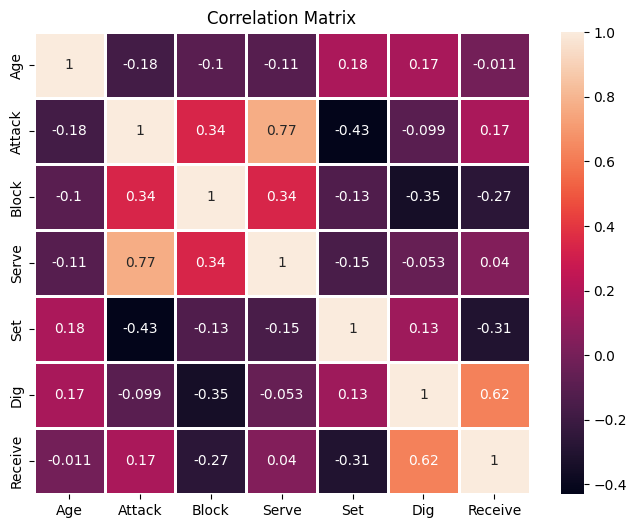

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, linewidths=2)
plt.title("Correlation Matrix")
plt.show()

In [32]:
position_counts = df["Position"].value_counts()
position_counts

Position
OH    42
MB    32
OP    25
S     16
L     16
Name: count, dtype: int64

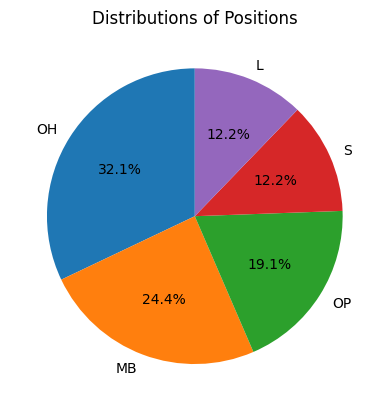

In [36]:
plt.pie(position_counts, labels=position_counts.index, startangle=90, autopct='%1.1f%%')
plt.title("Distributions of Positions")
plt.show()

In [41]:
avg_attack_by_country = df.groupby("Country")["Attack"].mean()
avg_attack_by_country = avg_attack_by_country.sort_values(ascending=False)

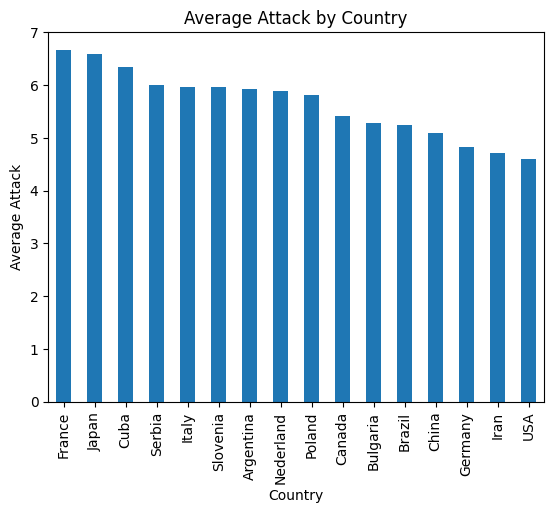

In [43]:
avg_attack_by_country.plot(kind = "bar")
plt.title("Average Attack by Country")
plt.xlabel("Country")
plt.ylabel("Average Attack")
plt.show()

In [48]:
df.groupby(["Position","Country"])["Attack"].max().reset_index().sort_values(ascending = False, by = "Attack")


,Position,Country,Attack
42,OH,Japan,15.80
59,OP,Nederland,15.33
54,OP,France,15.25
53,OP,Cuba,15.00
61,OP,Serbia,14.33
...,...,...,...
3,L,Canada,0.00
2,L,Bulgaria,0.00
1,L,Brazil,0.00
15,L,USA,0.00


In [51]:
df.groupby("Country")["Dig"].sum()

Country
Argentina    33.88
Brazil       24.61
Bulgaria     22.45
Canada       26.50
China        22.08
Cuba         20.26
France       38.59
Germany      20.92
Iran         24.25
Italy        35.89
Japan        32.38
Nederland    21.84
Poland       32.56
Serbia       30.64
Slovenia     33.85
USA          28.42
Name: Dig, dtype: float64

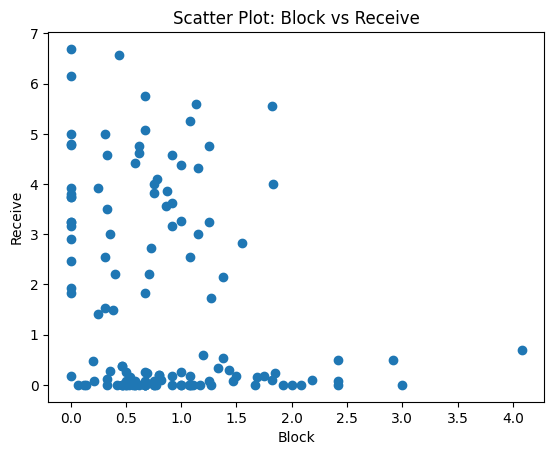

In [57]:
plt.scatter(df["Block"], df["Receive"])
plt.title("Scatter Plot: Block vs Receive")
plt.xlabel("Block")
plt.ylabel("Receive")
plt.show()


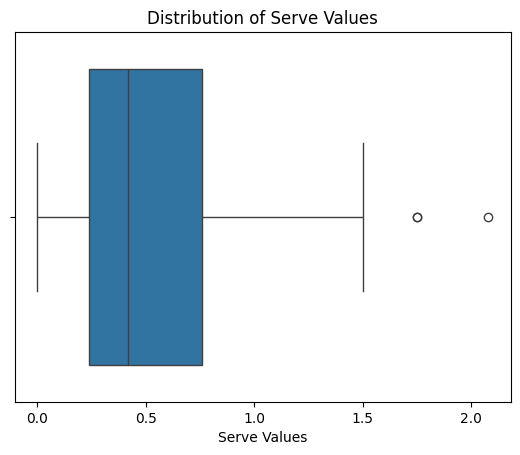

In [60]:
sns.boxplot(x = df["Serve"])
plt.title("Distribution of Serve Values")
plt.xlabel("Serve Values")
plt.show()


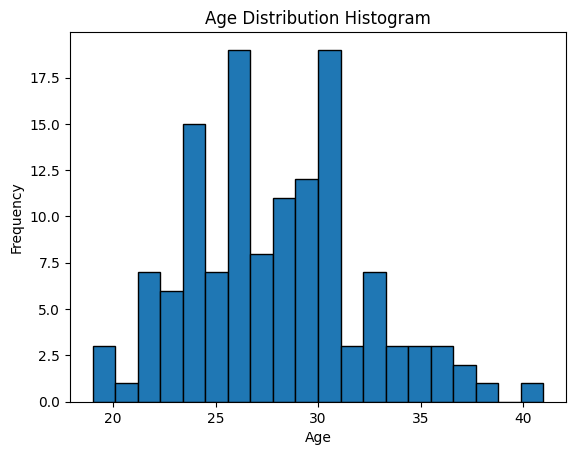

In [63]:
plt.hist(df["Age"], bins = 20, edgecolor = "black")
plt.title("Age Distribution Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

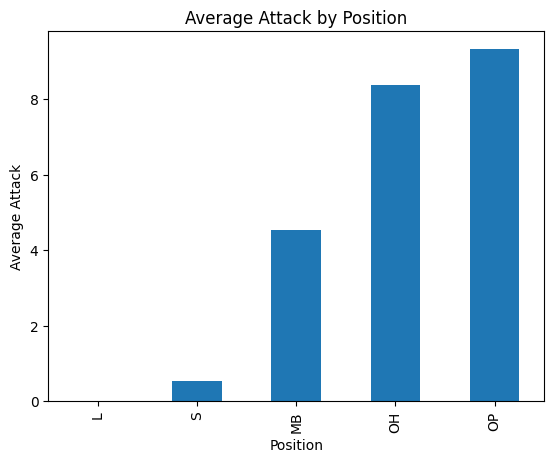

In [66]:
avg_attack_by_position = df.groupby("Position")["Attack"].mean().sort_values(ascending = True)
avg_attack_by_position.plot(kind = "bar")
plt.title("Average Attack by Position")
plt.xlabel("Position")
plt.ylabel("Average Attack")
plt.show()

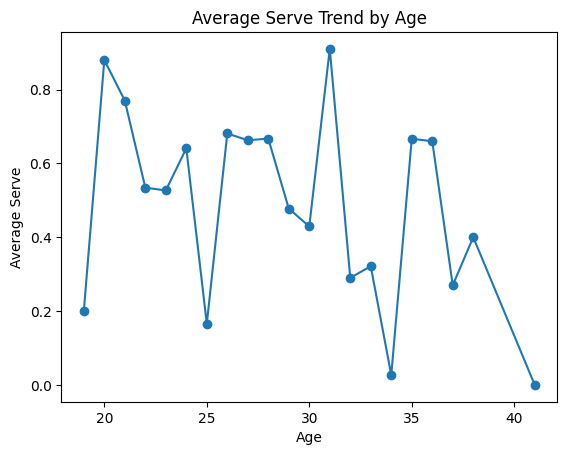

In [69]:
serve_trend_by_age = df.groupby('Age')["Serve"].mean()
serve_trend_by_age.plot(kind='line', marker = 'o', title='Average Serve Trend by Age')
plt.xlabel('Age')
plt.ylabel('Average Serve')
plt.show()

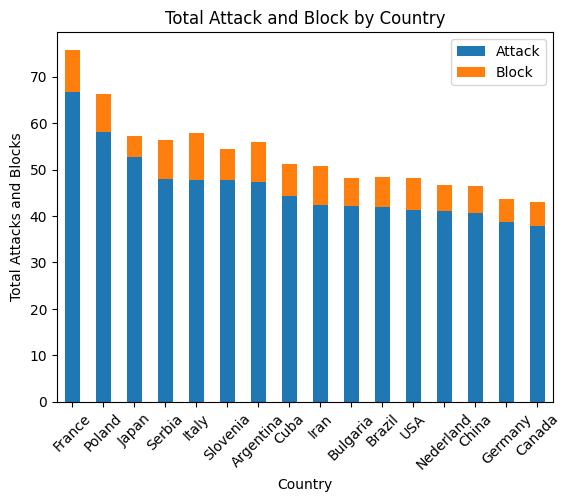

In [80]:
total_attack_and_block_by_country = df.groupby("Country")[["Attack", "Block"]].sum().sort_values(ascending = False, by = "Attack")
total_attack_and_block_by_country.plot(kind = "bar", stacked = True)
plt.title("Total Attack and Block by Country")
plt.xlabel("Country")
plt.ylabel("Total Attacks and Blocks")
plt.xticks(rotation=45)
plt.show()